# Contract Review — Fast Pipeline

**Path 1 + Path 2 combined notebook** — runs end-to-end in under 2 minutes on CPU.

- **ML backbone**: TF-IDF + Logistic Regression on CUAD (28 clause types) — the model your teammates already identified as best
- **LLM layer**: GPT-4o for document type, plain-language summary, and risk explanation

No BERT, no Longformer, no LEDGAR transfer learning — those take hours on Mac without GPU and aren't needed for the end product.

## Sections

0. Setup
1. Load CUAD
2. EDA + clause filtering + train/val/test split
3. Train TF-IDF + Logistic Regression (~30 sec)
4. Evaluate — per-clause F1, confusion matrix
5. End-to-end demo: classify + summarize + flag risks with GPT-4o
6. Export checkpoint for the Streamlit webapp

## Section 0 — Setup

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd()))

from data_loading import load_cuad
from preprocessing import (
    filter_clauses, plot_clause_frequency, build_clause_mappings,
    build_contract_records, split_contract_records,
)
from training import train_tfidf_lr
from evaluation import (
    tune_per_clause_thresholds, compute_per_clause_metrics,
    compute_aggregate_metrics, plot_confusion_matrix,
)

# OpenAI client
from openai import OpenAI

# Load API key from .streamlit/secrets.toml so the notebook and webapp share one source
import tomllib
with open('.streamlit/secrets.toml', 'rb') as f:
    _secrets = tomllib.load(f)
os.environ['OPENAI_API_KEY'] = _secrets['OPENAI_API_KEY']
oai = OpenAI()

print('Environment ready.')

Environment ready.


## Section 1 — Load CUAD

In [2]:
cuad_df = load_cuad('data/cuad')
cuad_df.head(3)

CUAD loaded: 510 contracts, 41 clause types, 20,910 rows, positive rate 32.05%


,contract_title,clause_type,question,contract_text,has_answer,answer_texts,answer_starts,answer_count
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,True,[DISTRIBUTOR AGREEMENT],[44],1
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,True,"[Distributor, Electric City Corp., Electric Ci...","[244, 148, 49574, 197, 212]",5
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Agreement Date,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,True,"[7th day of September, 1999.]",[263],1


## Section 2 — EDA + Clause Filtering + Split

/Users/saiashwin/BT5153/.claude/worktrees/crazy-tharp-7c055d/preprocessing.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="positive_rate", y="clause_type", ax=ax, palette="crest")


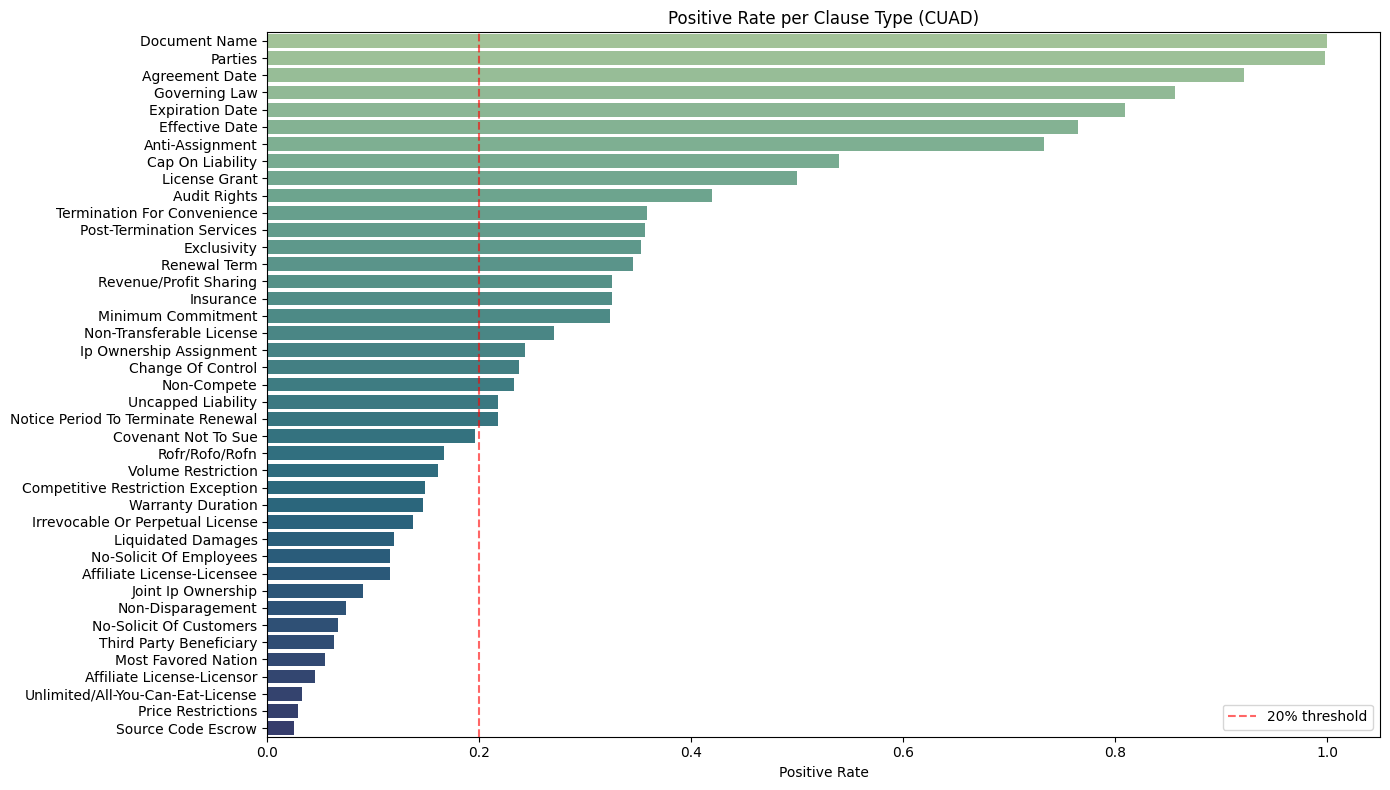

,clause_type,positive_rate,positive_count,total
0,Document Name,1.000000,510,510
1,Parties,0.998039,509,510
2,Agreement Date,0.921569,470,510
3,Governing Law,0.856863,437,510
4,Expiration Date,0.809804,413,510
5,Effective Date,0.764706,390,510
6,Anti-Assignment,0.733333,374,510
7,Cap On Liability,0.539216,275,510
8,License Grant,0.500000,255,510
9,Audit Rights,0.419608,214,510


In [3]:
# 2a: quick look at clause frequency
freq = plot_clause_frequency(cuad_df)
freq.head(10)

In [4]:
# 2b: drop clause types with fewer than 20 positive examples
cuad_filtered, excluded = filter_clauses(cuad_df, min_positives=20)

clause_to_id, id_to_clause = build_clause_mappings(cuad_filtered)
print(f'Kept {len(id_to_clause)} clause types; dropped {len(excluded)}.')

Excluded 3 clause types (below min_positives=20):
  Source Code Escrow: 13 positives
  Price Restrictions: 15 positives
  Unlimited/All-You-Can-Eat-License: 17 positives
Kept 38 clause types; dropped 3.


In [5]:
# 2c: split at contract level (80/10/10) so no contract appears in more than one split
contract_records = build_contract_records(cuad_filtered)
train_records, val_records, test_records = split_contract_records(contract_records, seed=42)

train_titles = {r['contract_title'] for r in train_records}
val_titles   = {r['contract_title'] for r in val_records}
test_titles  = {r['contract_title'] for r in test_records}

train_df = cuad_filtered[cuad_filtered['contract_title'].isin(train_titles)].copy()
val_df   = cuad_filtered[cuad_filtered['contract_title'].isin(val_titles)].copy()
test_df  = cuad_filtered[cuad_filtered['contract_title'].isin(test_titles)].copy()

print(f'Contracts — train: {len(train_titles)}, val: {len(val_titles)}, test: {len(test_titles)}')

Contracts — train: 408, val: 51, test: 51


## Section 3 — Train TF-IDF + Logistic Regression

Single model, ~30 seconds on CPU.

In [6]:
tfidf_artifacts = train_tfidf_lr(train_df, val_df, id_to_clause)
print('Done.')
print(f'Best global threshold (val): {tfidf_artifacts.best_threshold:.3f}')
print('Val metrics:', tfidf_artifacts.val_metrics)

TF-IDF + LR → val micro_F1=0.7936, threshold=0.55
Done.
Best global threshold (val): 0.550
Val metrics: {'micro_f1': 0.7936278059377263, 'micro_precision': 0.8094534711964549, 'micro_recall': 0.7784090909090909}


## Section 4 — Evaluation

In [ ]:
# 4a: tune per-clause thresholds on validation logits
# tune_per_clause_thresholds returns dict[clause_name -> threshold]
per_clause_thresholds = tune_per_clause_thresholds(
    tfidf_artifacts.val_logits,
    tfidf_artifacts.val_labels,
    tfidf_artifacts.id_to_clause,
)
print(f'Tuned thresholds for {len(per_clause_thresholds)} clauses.')
pd.Series(per_clause_thresholds, name='threshold').sort_values(ascending=False).head()

In [ ]:
# 4b: compute per-clause metrics using the tuned thresholds
def _count_train_positives(train_df, id_to_clause):
    name_to_id = {v: k for k, v in id_to_clause.items()}
    pos_count = {i: 0 for i in id_to_clause}
    for _, grp in train_df.groupby('contract_title'):
        for _, r in grp.iterrows():
            if r['has_answer'] and r['clause_type'] in name_to_id:
                pos_count[name_to_id[r['clause_type']]] += 1
    return pos_count

n_positive_train = _count_train_positives(train_df, tfidf_artifacts.id_to_clause)

per_clause_metrics = compute_per_clause_metrics(
    tfidf_artifacts.val_logits,
    tfidf_artifacts.val_labels,
    per_clause_thresholds,
    tfidf_artifacts.id_to_clause,
    n_positive_train,
)
# Already sorted by F1 descending
per_clause_metrics.head(10)

In [ ]:
# 4c: aggregate macro / micro F1
agg = compute_aggregate_metrics(
    tfidf_artifacts.val_logits,
    tfidf_artifacts.val_labels,
    per_clause_thresholds,
    id_to_clause=tfidf_artifacts.id_to_clause,
)
print('Aggregate validation metrics:')
for k, v in agg.items():
    print(f'  {k}: {v:.4f}')

In [ ]:
# 4d: bottom-5 clauses by F1 — where the model still struggles
per_clause_metrics.sort_values('f1').head(5)[[
    'clause_type', 'f1', 'precision', 'recall', 'n_positive_train'
]]

## Section 5 — End-to-End Demo (GPT-4o)

Pick a random contract from the test set, then run the full webapp pipeline against it:

1. **Clause detection** — TF-IDF + LR (fast, trained above)
2. **Document type** — GPT-4o
3. **Plain-English summary** — GPT-4o
4. **Risk flagging** — GPT-4o

This is the exact pipeline the Streamlit app uses, so anything that works here will work there.

In [ ]:
# 5a: pick a sample contract
sample_title = test_records[0]['contract_title']
sample_text = test_records[0]['contract_text']
print(f'Sample contract: {sample_title}')
print(f'Length: {len(sample_text):,} chars')
print('\n--- first 600 chars ---')
print(sample_text[:600])

In [ ]:
# 5b: detect clauses with TF-IDF + LR
proba = tfidf_artifacts.model.predict_proba([sample_text])[0]
eps = 1e-7
logits = np.log(np.clip(proba, eps, 1 - eps) / (1 - np.clip(proba, eps, 1 - eps)))

flagged_clauses = [
    id_to_clause[i] for i, logit in enumerate(logits)
    if logit >= tfidf_artifacts.best_threshold
]
print(f'Detected {len(flagged_clauses)} clause types:')
for c in flagged_clauses:
    print(f'  • {c}')

In [ ]:
# 5c: classify document type with GPT-4o
resp = oai.chat.completions.create(
    model='gpt-4o',
    temperature=0,
    messages=[
        {'role': 'system', 'content': (
            'You are a legal assistant. Identify the contract document type in 3–6 words '
            "(e.g. 'Non-Disclosure Agreement', 'Software License Agreement'). "
            'Reply with only the document type, nothing else.'
        )},
        {'role': 'user', 'content': f'Contract excerpt:\n\n{sample_text[:3000]}'},
    ],
)
doc_type = resp.choices[0].message.content.strip()
print('Document type:', doc_type)

In [ ]:
# 5d: plain-English summary with GPT-4o
resp = oai.chat.completions.create(
    model='gpt-4o',
    temperature=0.2,
    messages=[
        {'role': 'system', 'content': (
            'You are a legal assistant that explains contracts in plain English '
            'for people without a legal background. Be concise and avoid jargon.'
        )},
        {'role': 'user', 'content': (
            f'Summarize this {doc_type} in plain English using 4–6 bullet points. '
            'Cover: parties involved, key obligations, payment or duration, termination, '
            'and any unusual terms.\n\n'
            f'Contract:\n\n{sample_text[:6000]}'
        )},
    ],
)
summary = resp.choices[0].message.content.strip()
print(summary)

In [ ]:
# 5e: risk analysis with GPT-4o
clause_list = '\n'.join(f'- {c}' for c in flagged_clauses)
prompt = (
    'You are a legal risk analyst. The following clause types were detected in a contract.\n'
    "For each clause, return a JSON array under the key 'clauses' where every element has these exact keys:\n"
    "  clause (string), risk_level ('Low'|'Medium'|'High'), "
    'plain_explanation (1–2 sentences in plain English), '
    'watch_out_for (one concrete thing the signer should be cautious about).\n\n'
    f'Detected clauses:\n{clause_list}\n\n'
    f'Relevant contract text:\n\n{sample_text[:8000]}\n'
)

resp = oai.chat.completions.create(
    model='gpt-4o',
    temperature=0,
    messages=[
        {'role': 'system', 'content': 'You are a legal risk analyst. Output only valid JSON.'},
        {'role': 'user', 'content': prompt},
    ],
    response_format={'type': 'json_object'},
)
parsed = json.loads(resp.choices[0].message.content)
risks = parsed.get('clauses', parsed if isinstance(parsed, list) else [])

risk_df = pd.DataFrame(risks)
risk_df

## Section 6 — Export Checkpoint for Streamlit Webapp

In [ ]:
import joblib

Path('checkpoints').mkdir(exist_ok=True)
ckpt_path = 'checkpoints/tfidf_lr_artifacts.joblib'

joblib.dump({
    'model': tfidf_artifacts.model,
    'best_threshold': tfidf_artifacts.best_threshold,
    'id_to_clause': tfidf_artifacts.id_to_clause,
}, ckpt_path)

print(f'Checkpoint saved to {ckpt_path}')
print(f'  Clauses: {len(tfidf_artifacts.id_to_clause)}')
print(f'  Threshold: {tfidf_artifacts.best_threshold:.4f}')
print()
print('Now launch the webapp:')
print('  streamlit run webapp/app.py')